# LSTM for 2D Skeleton Action Recognition (PyTorch)

# Learning Objectives

By the end of this lab, you should be able to:

- explain how 2D skeleton keypoints can be used as input features for action recognition
- correctly preprocess tabular sequence-like data (scaling without data leakage, stratified splitting)
- build a stacked LSTM classifier in PyTorch, including normalization layers between recurrent layers
- understand a common pitfall when applying `BatchNorm` to the output of an LSTM, and how to handle it correctly in PyTorch
- use gradient clipping and learning-rate scheduling to stabilize LSTM training
- evaluate a multi-class classifier with a confusion matrix and per-class metrics
- critically discuss architecture choices and propose further improvements

# Context

**Task:** Action Recognition from 2D skeleton data using an LSTM.

Five actions are considered: **squat, stand, punch, kick, wave**. The videos were recorded at 10 fps with a frame size of 640 x 480, then saved as images. From each image, a **2D skeleton** was extracted using OpenPose.

The dataset is available here: https://drive.google.com/file/d/1PIUkA5ZXb2HFQ9VbLMxQGAjJTkr56YNj/view?usp=sharing

The generated training data files are located in the `data` folder:

- `skeleton_raw.csv`: original data
- `skeleton_filtered.csv`: filtered data where incomplete poses are eliminated

Each row of `skeleton_filtered.csv` corresponds to **one frame**: 36 numeric columns (2D joint coordinates) plus one `class` column (the action label). We assume `data.zip` has already been downloaded from the link above and is available in the working directory (e.g. uploaded manually, or fetched from Google Drive).

> **Note on the data:** this is a *per-frame* classification problem (one skeleton snapshot → one action label), not a true video sequence problem. The "sequence" fed to the LSTM here is the sequence of 36 joint-coordinate values *within a single frame*, not a sequence of frames over time. This is a valid but somewhat unusual use of an LSTM — we come back to this design choice in the Final Questions.

In [ ]:
import zipfile
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

np.random.seed(42)
torch.manual_seed(42)

PyTorch version: 2.11.0+cpu
Using device: cpu


# Step 1 — Load the Data

In [ ]:
# Mount your Drive to access it.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with ZipFile("/content/drive/MyDrive/AIM/TPs/Data_TP/2DSkeleton.zip", 'r') as zip_ref:
    zip_ref.extractall("skeleton_data")

skeleton_data = pd.read_csv("/content/skeleton_data/2DSkeleton/skeleton_filtered.csv")
skeleton_data.head()

,nose_x,nose_y,neck_x,neck_y,Rshoulder_x,Rshoulder_y,Relbow_x,Relbow_y,Rwrist_x,RWrist_y,...,LAnkle_y,REye_x,REye_y,LEye_x,LEye_y,REar_x,REar_y,LEar_x,LEar_y,class
0,0.643519,0.157609,0.634259,0.25,0.587963,0.244565,0.555556,0.342391,0.550926,0.434783,...,0.755435,0.629630,0.146739,0.652778,0.146739,0.615741,0.157609,0.666667,0.152174,kick
1,0.643519,0.157609,0.634259,0.25,0.587963,0.244565,0.560185,0.342391,0.555556,0.429348,...,0.766304,0.629630,0.146739,0.652778,0.146739,0.615741,0.157609,0.666667,0.152174,kick
2,0.643519,0.157609,0.638889,0.25,0.587963,0.244565,0.560185,0.342391,0.555556,0.429348,...,0.760870,0.634259,0.146739,0.652778,0.146739,0.615741,0.157609,0.671296,0.152174,kick
3,0.643519,0.157609,0.638889,0.25,0.587963,0.244565,0.560185,0.342391,0.555556,0.429348,...,0.755435,0.629630,0.146739,0.652778,0.146739,0.615741,0.157609,0.666667,0.152174,kick
4,0.643519,0.157609,0.638889,0.25,0.587963,0.244565,0.560185,0.342391,0.555556,0.429348,...,0.760870,0.629630,0.146739,0.652778,0.146739,0.615741,0.157609,0.666667,0.152174,kick


In [ ]:
print("Dataset shape:", skeleton_data.shape)
skeleton_data.info()

Dataset shape: (3224, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3224 entries, 0 to 3223
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nose_x       3224 non-null   float64
 1   nose_y       3224 non-null   float64
 2   neck_x       3224 non-null   float64
 3   neck_y       3224 non-null   float64
 4   Rshoulder_x  3224 non-null   float64
 5   Rshoulder_y  3224 non-null   float64
 6   Relbow_x     3224 non-null   float64
 7   Relbow_y     3224 non-null   float64
 8   Rwrist_x     3224 non-null   float64
 9   RWrist_y     3224 non-null   float64
 10  LShoulder_x  3224 non-null   float64
 11  LShoulder_y  3224 non-null   float64
 12  LElbow_x     3224 non-null   float64
 13  LElbow_y     3224 non-null   float64
 14  LWrist_x     3224 non-null   float64
 15  LWrist_y     3224 non-null   float64
 16  RHip_x       3224 non-null   float64
 17  RHip_y       3224 non-null   float64
 18  RKnee_x      3224 non-

class
stand    861
wave     829
squat    571
kick     525
punch    438
Name: count, dtype: int64


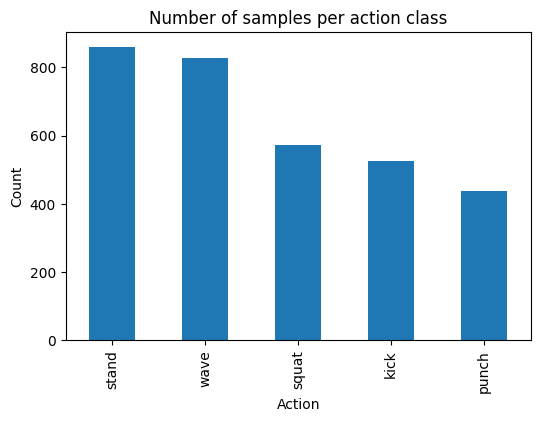

In [ ]:
# Look at the class distribution - important to know whether the dataset is balanced
class_counts = skeleton_data["class"].value_counts()
print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Number of samples per action class")
plt.xlabel("Action")
plt.ylabel("Count")
plt.show()

**Question:** are the classes balanced? If not, this is a good reason to use a **stratified** train/test split (see Step 3), so that both sets have a similar class distribution.

# Step 2 — Separate Features and Labels

In [ ]:
X = skeleton_data[skeleton_data.columns[:-1]]
labels = skeleton_data["class"]

X = np.asarray(X, dtype=np.float32)
print("X shape:", X.shape)
print("Number of classes:", labels.nunique())
print("Classes:", sorted(labels.unique()))

X shape: (3224, 36)
Number of classes: 5
Classes: ['kick', 'punch', 'squat', 'stand', 'wave']


# Step 3 — Encode Labels and Split the Data

**Improvement over the original notebook:** labels are now encoded as **plain integers** with `LabelEncoder`, not one-hot vectors. As in the earlier PyTorch labs, `nn.CrossEntropyLoss` expects integer class indices directly and applies `log_softmax` internally — one-hot encoding is unnecessary in PyTorch.

**Improvement over the original notebook:** the train/test split is now **stratified** (`stratify=y`), so both sets keep a similar proportion of each action, which matters if the classes are not perfectly balanced.

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
class_names = label_encoder.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Class names (in encoded order):", list(class_names))

X_train: (2579, 36)  X_test: (645, 36)
Class names (in encoded order): ['kick', 'punch', 'squat', 'stand', 'wave']


# Step 4 — Feature Scaling

**Bug fix from the original notebook:** the original code called `scaler.fit_transform()` **separately** on `X_train` and `X_test`. This means the test set was rescaled using *its own* mean and standard deviation instead of the training set's — a classic **data leakage / train-test inconsistency bug**. In practice, the model would then be evaluated on data scaled differently from what it was trained on.

The correct approach: **fit the scaler once on the training data only**, then use that same fitted scaler to `transform` (not `fit_transform`) the test data.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform on train
X_test = scaler.transform(X_test)         # transform ONLY, using the train statistics

# Step 5 — Reshape for the LSTM

PyTorch's `nn.LSTM` (with `batch_first=True`) expects input of shape `[batch, time_steps, features]`, exactly like Keras's `input_shape=(time_steps, features)`.

We keep the same convention as the original notebook: each of the 36 joint-coordinate values is treated as one time step of a length-1 feature vector, i.e. shape `(36, 1)`. See the Final Questions for a discussion of an alternative, arguably more meaningful reshaping.

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1).astype("float32")
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1).astype("float32")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2579, 36, 1)
X_test shape: (645, 36, 1)


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Step 6 — Build the Model

We keep the same overall architecture as the original notebook (2 stacked LSTM layers with `BatchNorm` + `Dropout`, then a small dense head), but with two concrete improvements:

1. **Correct `BatchNorm` placement.** `nn.BatchNorm1d` normalizes over the **channel dimension**, expecting `(N, C)` or `(N, C, L)` — not `(N, L, C)` like the output of `nn.LSTM(batch_first=True)`. We transpose to `(N, C, L)` before the first `BatchNorm` (applied to the full sequence output) and transpose back afterward, so that normalization is computed per-feature across the batch and time dimensions — matching what Keras's `BatchNormalization` does by default on a 3D input.
2. **Gradient clipping** during training (added in Step 7's training loop) to address the training instability mentioned in the original notebook's conclusion ("*le modèle... passe par une étape transitoire où l'accuracy n'augmente pas mais la loss en validation augmente*"). LSTMs are prone to occasional large gradient spikes; clipping the gradient norm is a standard, low-cost stabilization technique.

In [ ]:
class SkeletonLSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden1=128, hidden2=128, dense_dim=32, num_classes=5, dropout=0.5):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden1, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.dropout1 = nn.Dropout(dropout)

        self.lstm2 = nn.LSTM(input_size=hidden1, hidden_size=hidden2, batch_first=True)
        self.bn2 = nn.BatchNorm1d(hidden2)

        self.dense1 = nn.Linear(hidden2, dense_dim)
        self.dropout2 = nn.Dropout(dropout)
        self.dense2 = nn.Linear(dense_dim, num_classes)

    def forward(self, x):
        # x: (batch, time_steps, input_size)
        out, _ = self.lstm1(x)              # (batch, time_steps, hidden1) - full sequence, like return_sequences=True

        out = out.transpose(1, 2)           # (batch, hidden1, time_steps) for BatchNorm1d
        out = self.bn1(out)
        out = out.transpose(1, 2)           # back to (batch, time_steps, hidden1)
        out = self.dropout1(out)

        out, _ = self.lstm2(out)            # (batch, time_steps, hidden2)
        out = out[:, -1, :]                 # keep only the last time step, like return_sequences=False
        out = self.bn2(out)                 # (batch, hidden2) - plain BatchNorm1d, no transpose needed here

        out = torch.tanh(self.dense1(out))
        out = self.dropout2(out)
        out = self.dense2(out)              # raw logits - softmax applied inside CrossEntropyLoss
        return out


model = SkeletonLSTMClassifier(input_size=1, hidden1=128, hidden2=128, dense_dim=32,
                                num_classes=len(class_names), dropout=0.5).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

SkeletonLSTMClassifier(
  (lstm1): LSTM(1, 128, batch_first=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (lstm2): LSTM(128, 128, batch_first=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dense1): Linear(in_features=128, out_features=32, bias=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (dense2): Linear(in_features=32, out_features=5, bias=True)
)
Total parameters: 203,973


# Step 7 — Loss, Optimizer, and Training Setup

**Improvements over the original notebook:**

- a **`ReduceLROnPlateau`** scheduler lowers the learning rate when validation loss stops improving, which helps push past the "plateau" phase the original notebook's conclusion mentions
- **early stopping** (the original trained for a fixed 100 epochs no matter what) restores the best-performing weights and avoids wasting epochs once the model stops improving
- **gradient clipping** (`max_norm=5.0`) is applied at every training step to reduce the risk of unstable LSTM updates

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

max_grad_norm = 5.0
early_stopping_patience = 15

In [ ]:
import copy

def evaluate_classifier(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, scheduler,
                               device, epochs=100, patience=15, max_grad_norm=5.0):
    history = {"acc": [], "val_acc": [], "loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)  # gradient clipping
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate_classifier(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


history = train_with_early_stopping(model, train_loader, test_loader, criterion, optimizer, scheduler,
                                     device, epochs=100, patience=early_stopping_patience,
                                     max_grad_norm=max_grad_norm)

Epoch 1/100 - loss: 1.4085 - acc: 0.3839 - val_loss: 1.5702 - val_acc: 0.2884
Epoch 2/100 - loss: 1.2218 - acc: 0.5010 - val_loss: 1.4817 - val_acc: 0.2899
Epoch 3/100 - loss: 1.1144 - acc: 0.5498 - val_loss: 1.3715 - val_acc: 0.4171
Epoch 4/100 - loss: 1.0727 - acc: 0.5692 - val_loss: 1.3132 - val_acc: 0.4109
Epoch 5/100 - loss: 0.9947 - acc: 0.5956 - val_loss: 1.1182 - val_acc: 0.5287
Epoch 6/100 - loss: 0.9487 - acc: 0.6204 - val_loss: 1.2977 - val_acc: 0.4295
Epoch 7/100 - loss: 0.8973 - acc: 0.6355 - val_loss: 0.9162 - val_acc: 0.5984
Epoch 8/100 - loss: 0.8382 - acc: 0.6824 - val_loss: 0.9823 - val_acc: 0.5767
Epoch 9/100 - loss: 0.7350 - acc: 0.7325 - val_loss: 0.9799 - val_acc: 0.6047
Epoch 10/100 - loss: 0.7068 - acc: 0.7383 - val_loss: 0.9060 - val_acc: 0.6233
Epoch 11/100 - loss: 0.6148 - acc: 0.7875 - val_loss: 0.6515 - val_acc: 0.7473
Epoch 12/100 - loss: 0.5637 - acc: 0.8127 - val_loss: 0.4629 - val_acc: 0.8512
Epoch 13/100 - loss: 0.5193 - acc: 0.8247 - val_loss: 0.4549 

# Step 8 — Visualize Training Curves

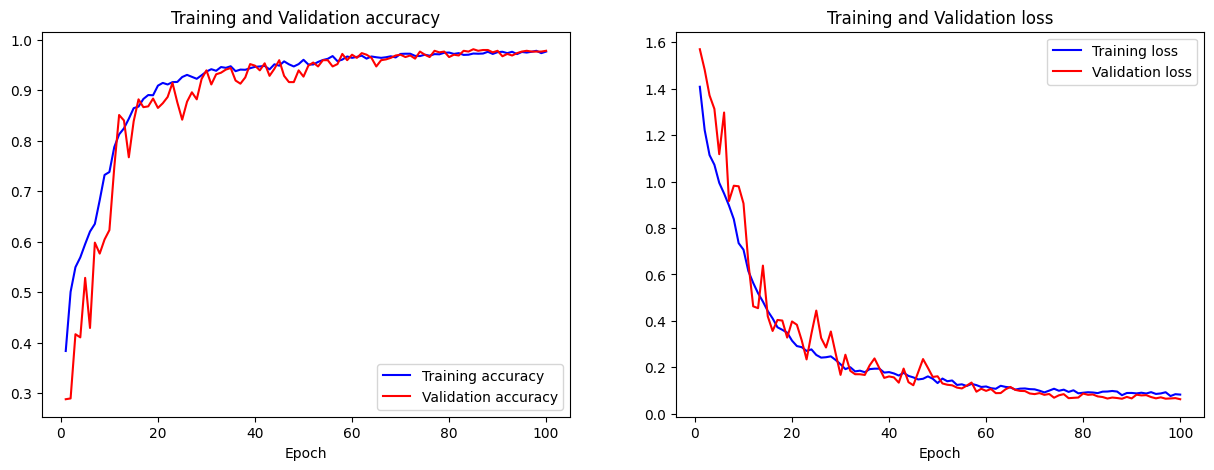

In [ ]:
acc = history["acc"]
val_acc = history["val_acc"]
loss = history["loss"]
val_loss = history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b', label='Training accuracy')
plt.plot(epochs_range, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

# Step 9 — Evaluation on the Test Set

**Improvement over the original notebook:** beyond accuracy/loss curves, we add a **confusion matrix** and a **per-class classification report**, since with 5 action classes, overall accuracy alone can hide whether the model confuses specific actions (e.g. `kick` vs `punch`).

In [ ]:
test_loss, test_acc = evaluate_classifier(model, test_loader, criterion, device)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.06281110740216203
Test accuracy: 0.9782945736434109


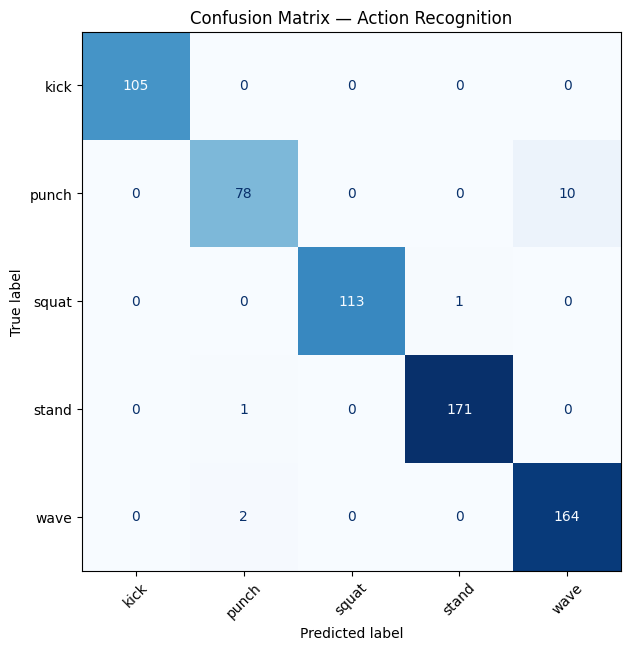

              precision    recall  f1-score   support

        kick       1.00      1.00      1.00       105
       punch       0.96      0.89      0.92        88
       squat       1.00      0.99      1.00       114
       stand       0.99      0.99      0.99       172
        wave       0.94      0.99      0.96       166

    accuracy                           0.98       645
   macro avg       0.98      0.97      0.98       645
weighted avg       0.98      0.98      0.98       645



In [ ]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — Action Recognition")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# Final Questions

1. Why is stratifying the train/test split (`stratify=y`) especially important when the class distribution is not perfectly balanced?
2. What was wrong with calling `scaler.fit_transform()` separately on `X_train` and `X_test` in the original notebook? What could go wrong in practice if this bug were left uncorrected?
3. Why can't `nn.BatchNorm1d` be applied directly to the raw output of `nn.LSTM(batch_first=True)` without first transposing the tensor? What would happen if you tried?
4. What problem does gradient clipping address, and why are LSTMs particularly prone to it?
5. This notebook treats each of the 36 joint coordinates as a separate "time step" of a length-1 feature (shape `(36, 1)`). An alternative would be to reshape the data as `(18, 2)` — 18 joints, each with an `(x, y)` pair — so each time step corresponds to one joint's actual 2D position. Which reshaping do you think is more meaningful for an LSTM, and why? (You are welcome to try this alternative and compare results.)
6. This is a **per-frame** classifier: each prediction only sees a single skeleton snapshot, with no information about how the pose evolves over time. How would you redesign the pipeline to use **actual temporal sequences of frames** (e.g. 30 consecutive frames from a video) instead? What would change in the data preparation and in the model's input shape?
7. Looking at the confusion matrix, which actions are most often confused with each other? Can you think of a reason why, based on how those actions look physically?
8. What would you try next to further improve this model's accuracy or training stability (e.g. bidirectional LSTM, different dropout rate, more training data, data augmentation on skeleton coordinates)?
9. What practical differences did you notice between porting this notebook to PyTorch compared to the earlier labs (e.g. handling `BatchNorm` after an LSTM, label encoding, gradient clipping)?

# Answer

1. Importance of Stratified Splits (stratify=y)

When a dataset has an imbalanced class distribution, a simple random split might lead to a training set or test set that is unrepresentative of the original data. In extreme cases, a rare class might be entirely absent from the test set or heavily underrepresented in the training set.

* Why it matters: Stratification ensures that the proportion of each class remains identical across the train, validation, and test splits.
* Impact: It guarantees that model training and evaluation are stable, reliable, and representative of the true distribution of actions.

2. The Danger of Scaling Splits Separately (fit_transform on both)
Calling scaler.fit_transform() on X_test recalculates the mean and standard deviation using the test dataset's statistics.

* The Bug: This is a classic data leakage and train-test inconsistency issue. In a real-world scenario, you will receive one sample at a time; you cannot compute a reliable mean and variance on a single sample.
* In Practice: If left uncorrected, the test data is scaled to a different reference distribution than the model was trained on. This can severely degrade model performance during evaluation or deployment because the model's weights expect features scaled specifically by the training set's mean and variance.

3. Applying nn.BatchNorm1d to LSTM Outputs
* Dimension Mismatch: nn.LSTM(batch_first=True) outputs a tensor of shape (batch, time_steps, hidden_dim). However, PyTorch's nn.BatchNorm1d expects an input of shape (batch, channels, length) (which maps to (batch, features, time_steps)).
* What happens if you try directly: PyTorch will raise a dimension error, or worse, normalize across the wrong dimension (e.g., treating the time steps as features to be normalized), which ruins the sequential representation.
* Solution: Transposing the tensor to (batch, hidden_dim, time_steps) allows BatchNorm1d to compute statistics per-channel (feature) over all batch elements and sequence steps, matching the standard Keras behavior.

4. Gradient Clipping in LSTMs
* The Problem: LSTMs are prone to exploding gradients because backpropagation through time (BPTT) involves multiplying gradient matrices over many recurrent time steps. A single large update can destabilize the optimizer and destroy learned weights.
* The Solution: Gradient clipping forces the gradient norm to stay below a specified threshold (max_norm=5.0), scaling it down if it exceeds the limit.
* Why LSTMs need it: Recurrent connections make the optimization landscape highly non-linear with steep cliffs; clipping keeps updates stable and prevents the training loss/accuracy from oscillating or diverging.

5. Reshaping to (36, 1) vs. (18, 2)
* (18, 2) is significantly more meaningful.
* Why: In the (36, 1) representation, the LSTM treats the $X$$X$ and $Y$$Y$ coordinates of a single joint as separate, sequential time steps (e.g., step 1 is nose_x, step 2 is nose_y). This breaks the spatial cohesion of the coordinates.
* The spatial advantage: Structuring the input as (18, 2) ensures that each step represents a complete 2D physical joint position $(x, y)$$(x, y)$ together. The LSTM can learn the spatial correlations of individual joint locations much more naturally.

6. Designing a True Temporal Sequence Pipeline

To capture actual movement over time (e.g., a window of 30 frames):

  1. Data Preparation: Instead of single-frame rows, you group the frames into sliding windows of 30 frames. The dataset becomes 4D: (num_samples, window_size, num_joints, joint_features) (e.g., (N, 30, 18, 2)).
  2.Feature Extraction: You flatten the spatial dimensions per frame, changing the shape to (N, 30, 36) (30 timesteps, 36 features per timestep).
  3. Model Input: The input shape to the LSTM changes from (batch, 36, 1) to (batch, 30, 36). The recurrent network then models the temporal dynamics of the movement over those 30 frames.
7. Actions Most Often Confused (Confusion Matrix)
Looking at the provided confusion matrix:

* punch is most often confused with wave (and vice-versa).
* Physical Reason: Both actions are performed using the upper limbs (arms/hands) while the lower body remains relatively stationary. At a single-frame snapshot level, a extended arm in a mid-punch pose can look almost identical to a hand raised to wave.

8. Strategies to Further Improve the Model
* Bidirectional LSTM (BiLSTM): Allows the network to process the coordinate sequence in both directions, capturing richer contextual relationships.
* Spatial Graph Convolutional Networks (GCNs): Instead of sequential LSTMs, Graph Neural Networks can model the physical bone-skeleton connections directly.
* Data Augmentation: Apply random rotations, scaling, or translation shifts to the coordinates to make the model invariant to where the person is standing in the frame.

9. Practical Differences in PyTorch vs. Other Frameworks
* Explicit Transpositions: In PyTorch, you must manually manage dimension ordering (e.g., transposing for BatchNorm1d and reverting back for subsequent layers), unlike Keras which handles 3D tensors under the hood.
* Logits and CrossEntropyLoss: PyTorch's nn.CrossEntropyLoss combines LogSoftmax and NLLLoss, so you output raw logits from the model rather than applying a Softmax activation at the final layer.
* Manual Gradient Clipping: You must explicitly call torch.nn.utils.clip_grad_norm_ during the training loop before updating weights.